# EVA-VaR: GEV

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import norm, t
from scipy.optimize import brentq
from arch import arch_model
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

---
## I. GARCH Specifications

All models share the mean equation $r_t = \mu + \sigma_t \varepsilon_t$ and differ in the variance equation and/or the innovation distribution.

---

### 1. GARCH(1,1) — Normal

$$\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2, \qquad \varepsilon_t \sim \mathcal{N}(0,1)$$

Stationarity: $\alpha + \beta < 1$. Unconditional variance: $\sigma^2 = \dfrac{\omega}{1-\alpha-\beta}$.
Initialise at unconditional variance to avoid burn-in effects.

---

### 2. GARCH(1,1) — Student-$t$

$$\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2, \qquad \varepsilon_t = \frac{Z}{\sqrt{V/\nu}} \cdot \sqrt{\frac{\nu-2}{\nu}}$$

where $Z \sim \mathcal{N}(0,1)$, $V \sim \chi^2(\nu)$ independently. The scaling factor $\sqrt{(\nu-2)/\nu}$ ensures $\operatorname{Var}(\varepsilon_t) = 1$. Requires $\nu > 4$ for finite kurtosis.

---

### 3. GJR-GARCH — asymmetric volatility (leverage effect)

$$\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2 + \delta\, \varepsilon_{t-1}^2\, \mathbf{1}\{\varepsilon_{t-1} < 0\}$$

The leverage term $\delta > 0$ captures the asymmetric response: negative shocks amplify variance more than positive shocks of equal size. Stationarity: $\alpha + \beta + \tfrac{1}{2}\delta < 1$. Unconditional variance: $\sigma^2 = \dfrac{\omega}{1 - \alpha - \beta - \frac{1}{2}\delta}$.

---

### 4. GARCH-in-Mean (GARCH-M)

$$r_t = \mu + \lambda\, \sigma_t + \sigma_t \varepsilon_t, \qquad \sigma_t^2 = \omega + \alpha r_{t-1}^2 + \beta \sigma_{t-1}^2$$

The mean equation includes $\sigma_t$ directly: higher conditional volatility is associated with a higher expected return (risk premium $\lambda$). We use $\sigma_t$ (not $\sigma_t^2$) to keep units consistent and prevent variance feedback from destabilising the process.

---
## II. Simulation Functions

In [2]:
def simulate_garch(n_obs=3000, mu=0.0, omega=0.05, alpha=0.1, beta=0.85, seed=None):
    if alpha + beta >= 1:
        raise ValueError('alpha + beta >= 1: process is non-stationary')
    if omega <= 0:
        raise ValueError('omega must be positive')

    rng = np.random.default_rng(seed)
    returns  = np.zeros(n_obs)
    variance = np.zeros(n_obs)

    unconditional_var = omega / (1 - alpha - beta)
    variance[0] = unconditional_var
    returns[0]  = mu + np.sqrt(variance[0]) * rng.standard_normal()

    for i in range(1, n_obs):
        variance[i] = omega + alpha * returns[i-1]**2 + beta * variance[i-1]
        returns[i]  = mu + np.sqrt(variance[i]) * rng.standard_normal()

    return returns, variance


def simulate_garch_t(n_obs=3000, mu=0.0, omega=0.05, alpha=0.1, beta=0.85, nu=6, seed=None):
    if alpha + beta >= 1:
        raise ValueError('alpha + beta >= 1: process is non-stationary')
    if nu <= 4:
        raise ValueError('nu > 4 required for finite kurtosis')

    rng = np.random.default_rng(seed)
    returns  = np.zeros(n_obs)
    variance = np.zeros(n_obs)

    unconditional_var = omega / (1 - alpha - beta)
    variance[0] = unconditional_var

    # scale raw t draws so that Var = 1
    scale = np.sqrt((nu - 2) / nu)
    returns[0] = mu + np.sqrt(variance[0]) * t.rvs(df=nu, random_state=rng) * scale

    for i in range(1, n_obs):
        variance[i] = omega + alpha * returns[i-1]**2 + beta * variance[i-1]
        eps = t.rvs(df=nu, random_state=rng) * scale
        returns[i] = mu + np.sqrt(variance[i]) * eps

    return returns, variance


def simulate_gjr_garch(n_obs=3000, mu=0.0, omega=0.05, alpha=0.05, beta=0.85, delta=0.1, seed=None):
    if alpha + beta + 0.5 * delta >= 1:
        raise ValueError('alpha + beta + 0.5*delta >= 1: process is non-stationary')

    rng = np.random.default_rng(seed)
    returns  = np.zeros(n_obs)
    variance = np.zeros(n_obs)

    unconditional_var = omega / (1 - alpha - beta - 0.5 * delta)
    variance[0] = unconditional_var
    returns[0]  = mu + np.sqrt(variance[0]) * rng.standard_normal()

    for i in range(1, n_obs):
        eps_prev  = returns[i-1] / np.sqrt(variance[i-1])   # lagged standardised innovation
        indicator = 1 if eps_prev < 0 else 0                  # leverage
        variance[i] = (omega
                       + alpha * returns[i-1]**2
                       + beta  * variance[i-1]
                       + delta * returns[i-1]**2 * indicator)
        returns[i] = mu + np.sqrt(variance[i]) * rng.standard_normal()

    return returns, variance


def simulate_garch_m(n_obs=3000, mu=0.0, lam=0.1, omega=0.05, alpha=0.1, beta=0.85, seed=None):
    if alpha + beta >= 1:
        raise ValueError('alpha + beta >= 1: process is non-stationary')

    rng = np.random.default_rng(seed)
    returns  = np.zeros(n_obs)
    variance = np.zeros(n_obs)

    unconditional_var = omega / (1 - alpha - beta)
    variance[0] = unconditional_var
    returns[0]  = mu + lam * np.sqrt(variance[0]) + np.sqrt(variance[0]) * rng.standard_normal()

    for i in range(1, n_obs):
        variance[i] = omega + alpha * returns[i-1]**2 + beta * variance[i-1]
        returns[i]  = mu + lam * np.sqrt(variance[i]) + np.sqrt(variance[i]) * rng.standard_normal()

    return returns, variance

---
## III. Choose Specification and Simulate

Set `SPEC` to one of: `'garch'`, `'garch_t'`, `'gjr_garch'`, `'garch_m'`

In [3]:
# ── choose specification here ────────────────────────────────────────────────
SPEC  = 'garch_t'  # options: 'garch', 'garch_t', 'gjr_garch', 'garch_m'

N_OBS = 100_000
SEED  = 42

# shared GARCH parameters
MU, OMEGA, ALPHA, BETA = 0.0, 0.05, 0.1, 0.85

if SPEC == 'garch':
    returns, variance = simulate_garch(N_OBS, mu=MU, omega=OMEGA, alpha=ALPHA, beta=BETA, seed=SEED)
    spec_label = 'GARCH(1,1) — Normal'

elif SPEC == 'garch_t':
    NU = 5
    returns, variance = simulate_garch_t(N_OBS, mu=MU, omega=OMEGA, alpha=ALPHA, beta=BETA, nu=NU, seed=SEED)
    spec_label = f'GARCH(1,1)-t  (ν={NU})'

elif SPEC == 'gjr_garch':
    DELTA = 0.1
    returns, variance = simulate_gjr_garch(N_OBS, mu=MU, omega=OMEGA, alpha=0.05, beta=BETA, delta=DELTA, seed=SEED)
    spec_label = 'GJR-GARCH(1,1)'

elif SPEC == 'garch_m':
    LAM = 0.1
    returns, variance = simulate_garch_m(N_OBS, mu=MU, lam=LAM, omega=OMEGA, alpha=ALPHA, beta=BETA, seed=SEED)
    spec_label = 'GARCH-M(1,1)'

else:
    raise ValueError(f'Unknown spec: {SPEC}')

cond_vol = np.sqrt(variance)
print(f'Specification : {spec_label}')
print(f'n_obs         : {N_OBS}')

Specification : GARCH(1,1)-t  (ν=5)
n_obs         : 100000


### Returns & conditional volatility

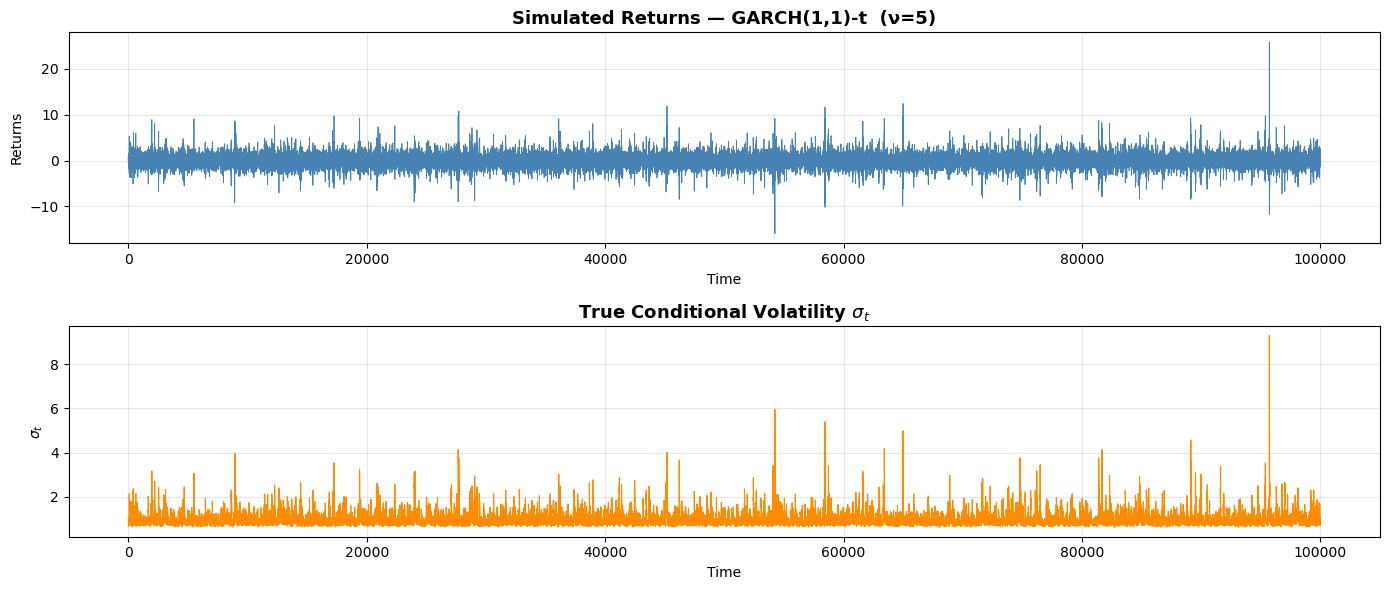

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

axes[0].plot(returns, linewidth=0.6, color='steelblue')
axes[0].set_title(f'Simulated Returns — {spec_label}', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Returns')
axes[0].grid(True, alpha=0.3)

axes[1].plot(cond_vol, linewidth=0.8, color='darkorange')
axes[1].set_title('True Conditional Volatility $\\sigma_t$', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('$\\sigma_t$')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Return distribution

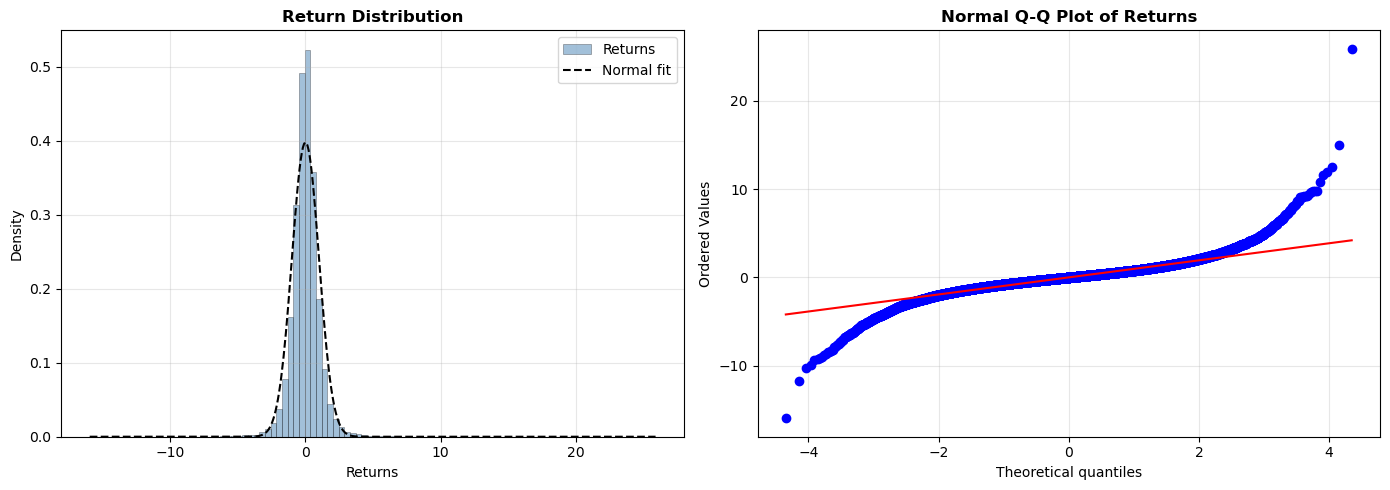

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_range = np.linspace(returns.min(), returns.max(), 500)

axes[0].hist(returns, bins=100, density=True, alpha=0.5,
             color='steelblue', edgecolor='black', linewidth=0.4, label='Returns')
axes[0].plot(x_range, norm.pdf(x_range, loc=np.mean(returns), scale=np.std(returns)),
             'k--', linewidth=1.5, label='Normal fit')
axes[0].set_title('Return Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Returns')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

stats.probplot(returns, dist='norm', plot=axes[1])
axes[1].set_title('Normal Q-Q Plot of Returns', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

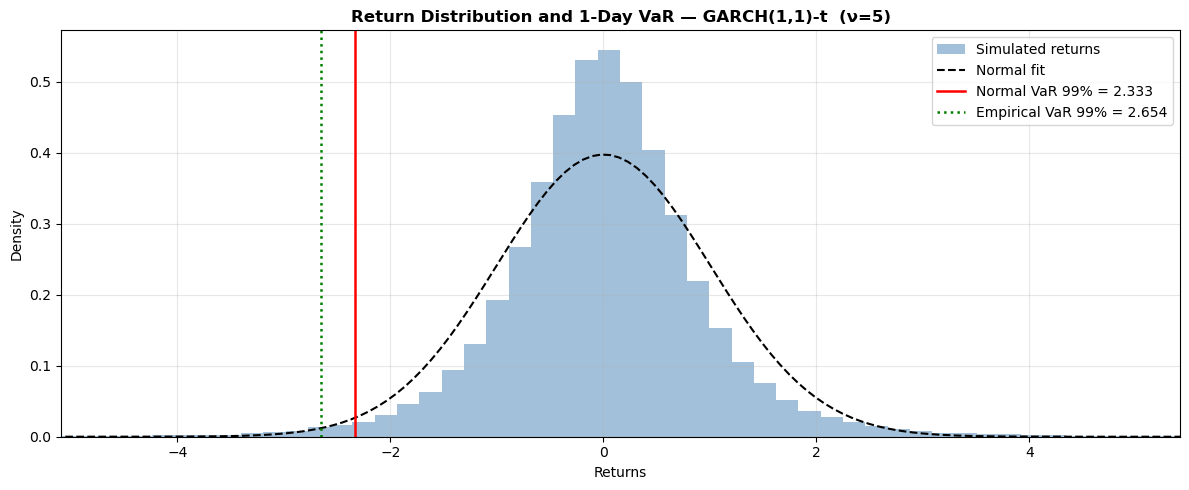

In [6]:
# ── Return distribution with unconditional 1-day Normal VaR ──────────────────
# P = 0.95
P = 0.99
mu, sd     = returns.mean(), returns.std()
var_normal = -(mu + sd * norm.ppf(1 - P))     # Normal VaR, reported as a positive loss
var_empir  = -np.quantile(returns, 1 - P)     # empirical benchmark

x = np.linspace(returns.min(), returns.max(), 500)

plt.figure(figsize=(12, 5))
plt.hist(returns, bins=200, density=True, alpha=0.5, color='steelblue', label='Simulated returns')
plt.plot(x, norm.pdf(x, mu, sd), 'k--', lw=1.5, label='Normal fit')
plt.axvline(-var_normal, color='red',   lw=1.8,          label=f'Normal VaR {P:.0%} = {var_normal:.3f}')
plt.axvline(-var_empir,  color='green', lw=1.8, ls=':',  label=f'Empirical VaR {P:.0%} = {var_empir:.3f}')

plt.xlim(np.quantile(returns, 0.001), np.quantile(returns, 0.999))
plt.title(f'Return Distribution and 1-Day VaR — {spec_label}', fontweight='bold')
plt.xlabel('Returns'); plt.ylabel('Density')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## IV. Fit GARCH(1,1) and Extract Residuals

We always fit a **GARCH(1,1) with Normal innovations** regardless of the true DGP — this is the standard filtering step.

$$\hat{e}_t = r_t - \hat{\mu} $$
$$\hat{\varepsilon}_t = \frac{\hat{e}_t}{\hat{\sigma}_t} \qquad \text{(standardised residuals)}$$

If the model is correctly specified, $\hat{\varepsilon}_t \overset{iid}{\approx} \mathcal{N}(0,1)$.

In [7]:
model = arch_model(returns, mean='constant', vol='GARCH', p=1, q=1, rescale=False)
res   = model.fit(disp='off')

print(res.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -133431.
Distribution:                  Normal   AIC:                           266870.
Method:            Maximum Likelihood   BIC:                           266908.
                                        No. Observations:               100000
Date:                Thu, Sep 10 2026   Df Residuals:                    99999
Time:                        21:00:24   Df Model:                            1
                                  Mean Model                                  
                  coef    std err          t      P>|t|       95.0% Conf. Int.
------------------------------------------------------------------------------
mu         -2.1274e-03  2.866e-03     -0.742      0.

In [8]:
raw_residuals = res.resid                  # e_t = r_t - mu_hat
cond_vol_fit  = res.conditional_volatility # sigma_t hat
std_residuals = res.std_resid              # eps_t = e_t / sigma_t hat

print(f'Standardized residuals — mean: {std_residuals.mean():.4f}, '
      f'std: {std_residuals.std():.4f}, '
      f'skew: {stats.skew(std_residuals):.4f}, '
      f'excess kurtosis: {stats.kurtosis(std_residuals):.4f}')

Standardized residuals — mean: 0.0018, std: 1.0000, skew: 0.0908, excess kurtosis: 4.2182


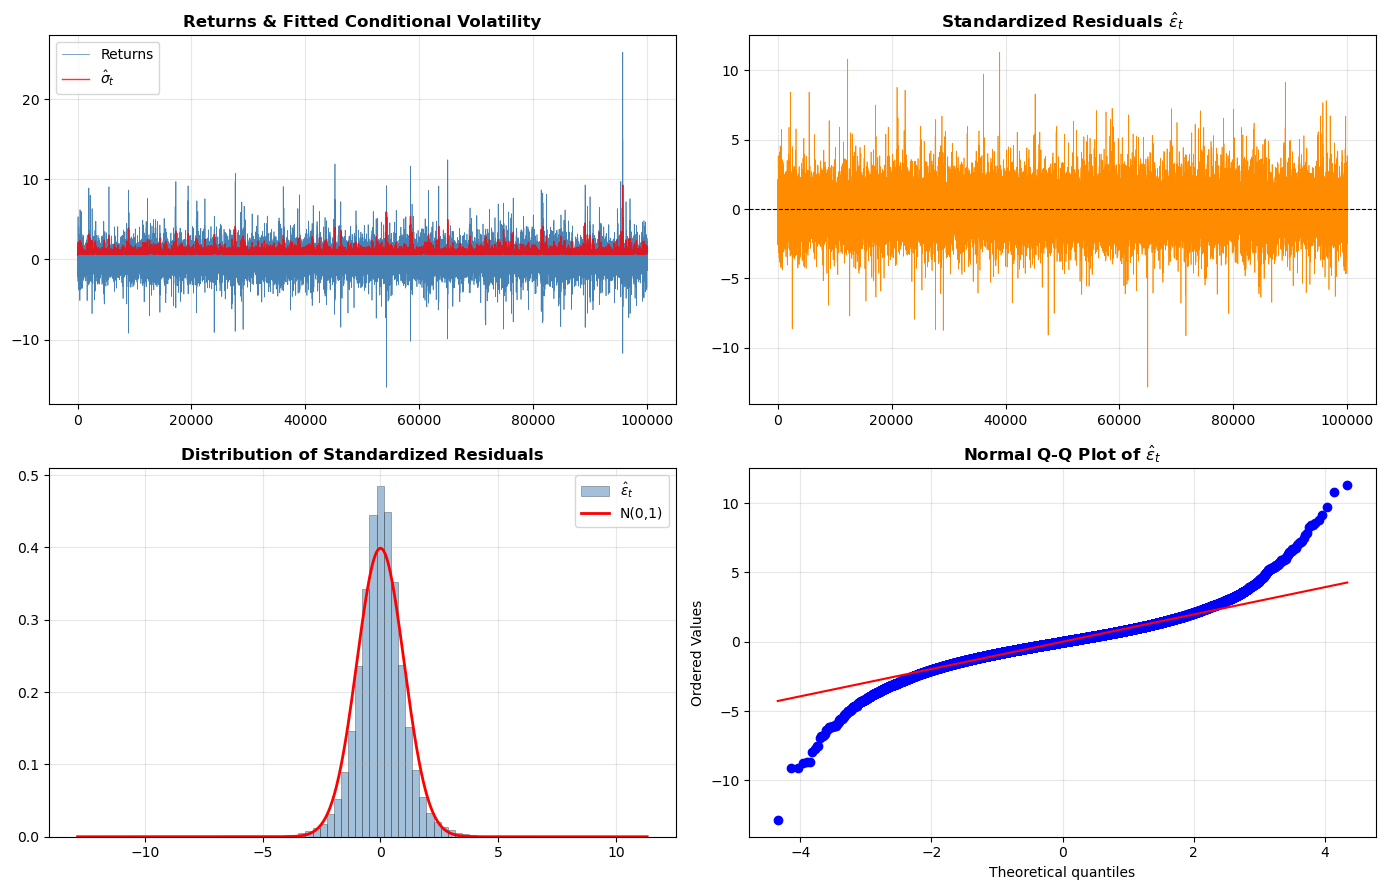

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# returns + fitted conditional volatility
axes[0, 0].plot(returns, linewidth=0.5, color='steelblue', label='Returns')
axes[0, 0].plot(cond_vol_fit, linewidth=1.0, color='red', alpha=0.8, label='$\\hat{\\sigma}_t$')
axes[0, 0].set_title('Returns & Fitted Conditional Volatility', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# standardised residuals over time
axes[0, 1].plot(std_residuals, linewidth=0.5, color='darkorange')
axes[0, 1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0, 1].set_title('Standardized Residuals $\\hat{\\varepsilon}_t$', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# histogram vs N(0,1)
x_range = np.linspace(std_residuals.min(), std_residuals.max(), 500)
axes[1, 0].hist(std_residuals, bins=80, density=True, alpha=0.5,
                color='steelblue', edgecolor='black', linewidth=0.4, label='$\\hat{\\varepsilon}_t$')
axes[1, 0].plot(x_range, norm.pdf(x_range), 'r-', linewidth=2, label='N(0,1)')
axes[1, 0].set_title('Distribution of Standardized Residuals', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# QQ-plot
stats.probplot(std_residuals, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Normal Q-Q Plot of $\\hat{\\varepsilon}_t$', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## V. ACF & PACF of Standardised Residuals

If GARCH is well-specified:
- $\hat{\varepsilon}_t$ should be white noise — no serial correlation
- All lags should fall within the confidence bands

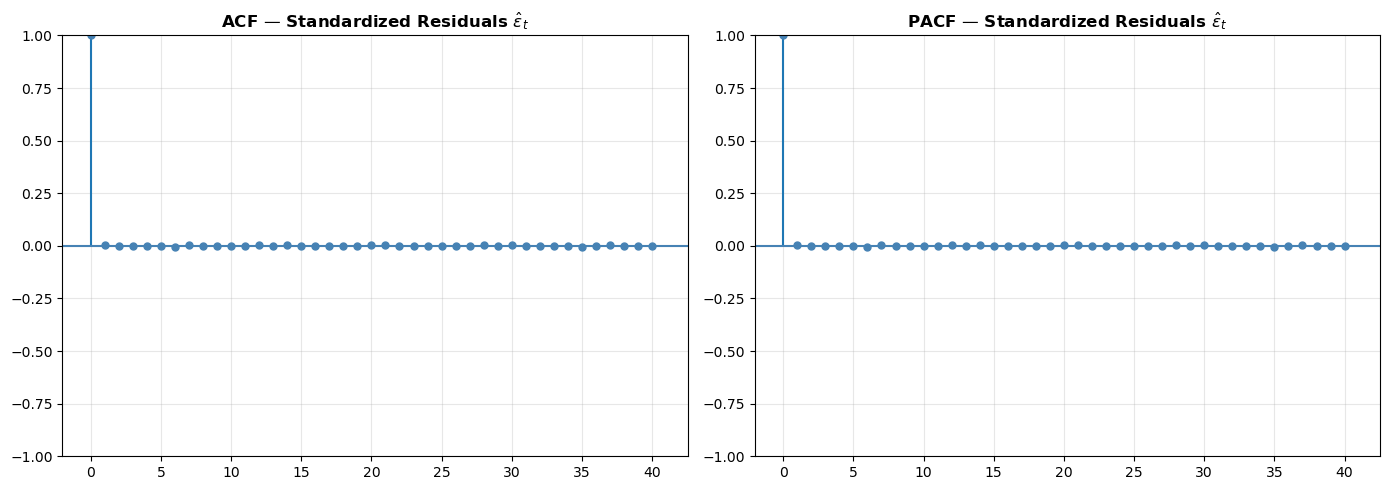

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(std_residuals, lags=40, ax=axes[0], color='steelblue')
axes[0].set_title('ACF — Standardized Residuals $\\hat{\\varepsilon}_t$', fontweight='bold')
axes[0].grid(True, alpha=0.3)

plot_pacf(std_residuals, lags=40, ax=axes[1], color='steelblue')
axes[1].set_title('PACF — Standardized Residuals $\\hat{\\varepsilon}_t$', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## VI. Tail Index Estimation

We focus on the **left tail** (losses). Define:
$$\text{losses}_t = -\hat{\varepsilon}_t$$
so that large losses become large positive values in the right tail of `losses`, which is what the Pickands estimator requires.

---

### Pickands (1975) Estimator

Let $X_{(1)} \geq X_{(2)} \geq \cdots \geq X_{(n)}$ be descending order statistics. Then:

$$\hat{\xi}_k^{P} = \frac{1}{\log 2} \log \left( \frac{X_{(k)} - X_{(2k)}}{X_{(2k)} - X_{(4k)}} \right)$$

- Consistent for **all** $\xi \in \mathbb{R}$ (Gumbel, Fréchet, and Weibull domains)
- Higher variance than Hill, but universally applicable
- Optimal $k^*$: look for the stable plateau (lowest rolling std / MSE)

---

### Hill (1975) Estimator

$$\hat{\xi}_k^{H} = \frac{1}{k} \sum_{i=1}^{k} \log X_{(i)} - \log X_{(k+1)}$$

- Valid **only** for $\xi > 0$ (power-law / Fréchet tails)
- More efficient than Pickands when $\xi > 0$
- Requires strictly positive data — shown here for diagnostic comparison only; the tail index used downstream (GEV and the GPD+GEV hybrid) is the **Pickands** estimate, since it is consistent regardless of the sign of $\xi$.

In [11]:
def pickands_estimator(data, k_min=5, k_max=2500):
    x = np.sort(data)[::-1]   # X_(1) >= X_(2) >= ...
    n = len(x)

    if k_max is None:
        k_max = n // 4 - 1

    ks  = np.arange(k_min, k_max + 1)
    xis = np.zeros(len(ks))

    for i, k in enumerate(ks):
        num = x[k - 1] - x[2*k - 1]     # X_(k)  - X_(2k)
        den = x[2*k - 1] - x[4*k - 1]   # X_(2k) - X_(4k)

        if den <= 0 or num <= 0:
            xis[i] = np.nan
        else:
            xis[i] = np.log(num / den) / np.log(2)

    return ks, xis


def select_k_pickands(ks, xis, window=20):
    # Select optimal k* as midpoint of the most stable window (min rolling std).
    # Returns: k_star, xi_star, rolling_std, ks_v, xis_v
    valid = ~np.isnan(xis)
    ks_v, xis_v = ks[valid], xis[valid]

    rolling_std = np.array([
        np.std(xis_v[i:i+window])
        for i in range(len(xis_v) - window + 1)
    ])

    best_start = np.argmin(rolling_std)
    k_star_idx = best_start + window // 2
    k_star  = ks_v[k_star_idx]
    xi_star = xis_v[k_star_idx]

    return k_star, xi_star, rolling_std, ks_v, xis_v


def hill_estimator(data, k_min=5, k_max=None):
    x = np.sort(data)[::-1]
    n = len(x)

    if np.any(x <= 0):
        raise ValueError('Hill estimator requires strictly positive data')

    if k_max is None:
        k_max = n // 2 - 1

    ks  = np.arange(k_min, k_max + 1)
    xis = np.zeros(len(ks))

    for i, k in enumerate(ks):
        xis[i] = np.mean(np.log(x[:k])) - np.log(x[k])

    return ks, xis


def select_k_hill(ks, xis, window=20):
    valid = ~np.isnan(xis)
    ks_v, xis_v = ks[valid], xis[valid]

    rolling_std = np.array([
        np.std(xis_v[i:i+window])
        for i in range(len(xis_v) - window + 1)
    ])

    # first local minimum, not the global one
    best_start = np.argmin(rolling_std[:len(rolling_std) // 2])
    k_star_idx = best_start + window // 2
    k_star  = ks_v[k_star_idx]
    xi_star = xis_v[k_star_idx]

    return k_star, xi_star, ks_v, xis_v

### Pickands Plot

Optimal k*  : 2194
xi_hat (P)  : 0.0506


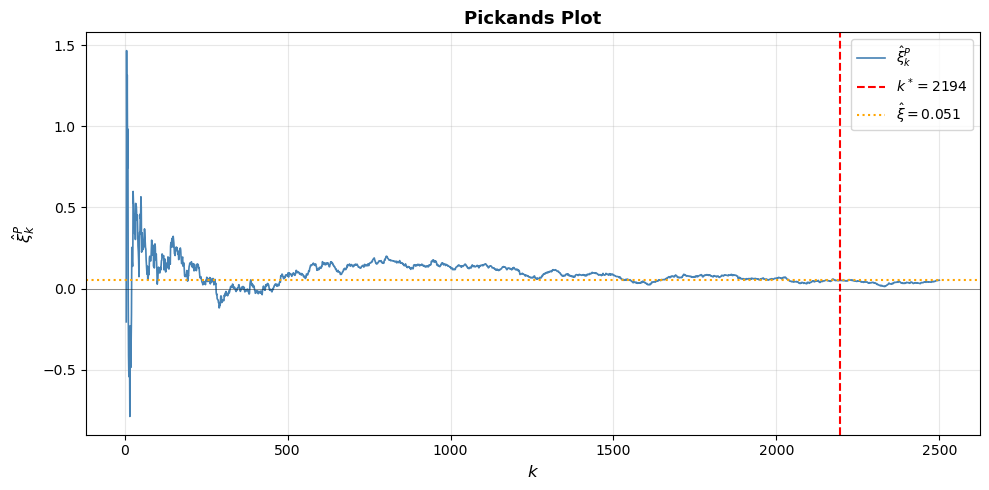

In [12]:
# negate residuals so that large losses -> large positive values in right tail
losses = -std_residuals

ks, xis = pickands_estimator(losses, k_min=5)
k_star, xi_star, rolling_std, ks_v, xis_v = select_k_pickands(ks, xis, window=20)

print(f'Optimal k*  : {k_star}')
print(f'xi_hat (P)  : {xi_star:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(ks_v, xis_v, color='steelblue', linewidth=1.2, label='$\\hat{\\xi}_k^P$')
ax.axvline(k_star, color='red', linestyle='--', linewidth=1.5, label=f'$k^* = {k_star}$')
ax.axhline(xi_star, color='orange', linestyle=':', linewidth=1.5, label=f'$\\hat{{\\xi}} = {xi_star:.3f}$')
ax.axhline(0, color='black', linewidth=0.7, linestyle='-', alpha=0.4)
ax.set_xlabel('$k$', fontsize=12)
ax.set_ylabel('$\\hat{\\xi}_k^P$', fontsize=12)
ax.set_title('Pickands Plot', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Block bootstrap

In [13]:
K_MAX = 1000

def block_bootstrap_pickands(data, block_size=2000, n_boot=200, window=20,
                             k_min=5, k_max=None, seed=0):

    rng = np.random.default_rng(seed)
    n = len(data)
    n_blocks = n // block_size

    k_boot  = np.zeros(n_boot, dtype=int)
    xi_boot = np.zeros(n_boot)

    for b in range(n_boot):
        starts = rng.integers(0, n - block_size + 1, size=n_blocks)
        sample = np.concatenate([data[s:s + block_size] for s in starts])

        ks_b, xis_b = pickands_estimator(sample, k_min=k_min, k_max=k_max)
        k_b, xi_b, _, _, _ = select_k_pickands(ks_b, xis_b, window=window)
        k_boot[b], xi_boot[b] = k_b, xi_b

    return k_boot, xi_boot


k_boot, xi_boot = block_bootstrap_pickands(losses, block_size=2000, n_boot=200,
                                           window=20, k_max=K_MAX, seed=0)

XI_BOOT = np.nanmean(xi_boot)          # proxy for the "true" xi
print(f'bootstrap mean xi : {XI_BOOT:.4f}')
print(f'bootstrap sd      : {np.nanstd(xi_boot):.4f}')
print(f'95% CI            : [{np.nanpercentile(xi_boot, 2.5):.4f}, '
      f'{np.nanpercentile(xi_boot, 97.5):.4f}]')
print(f'mean k*           : {k_boot.mean():.0f}')

bootstrap mean xi : 0.1457
bootstrap sd      : 0.0607
95% CI            : [0.0226, 0.2576]
mean k*           : 858


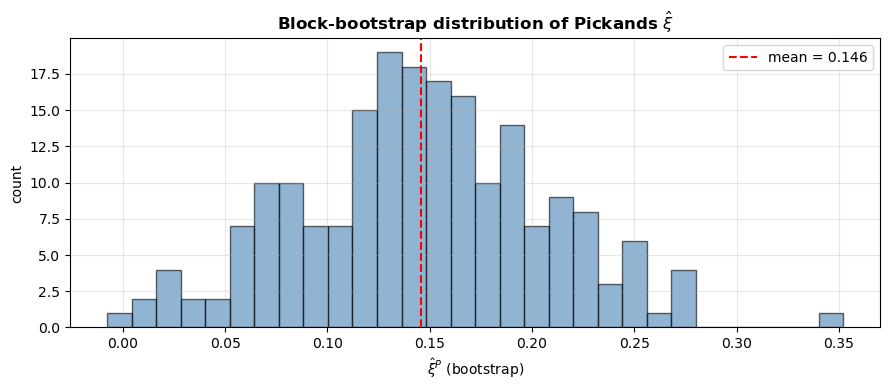

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(xi_boot, bins=30, color='steelblue', edgecolor='black', alpha=0.6)
ax.axvline(XI_BOOT, color='red', ls='--', lw=1.5, label=f'mean = {XI_BOOT:.3f}')
ax.set_xlabel('$\\hat{\\xi}^P$ (bootstrap)'); ax.set_ylabel('count')
ax.set_title('Block-bootstrap distribution of Pickands $\\hat{\\xi}$', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [15]:
def select_k_pickands_mse(ks, xis, xi_ref, window=20):
    valid = ~np.isnan(xis)
    ks_v, xis_v = ks[valid], xis[valid]

    mse, bias2, var = [], [], []
    for i in range(len(xis_v) - window + 1):
        w = xis_v[i:i + window]
        bias2.append((w.mean() - xi_ref) ** 2)
        var.append(w.var())
        mse.append(np.mean((w - xi_ref) ** 2))     # = bias^2 + var

    mse, bias2, var = np.array(mse), np.array(bias2), np.array(var)

    k_star_idx = np.argmin(mse) + window // 2
    return ks_v[k_star_idx], xis_v[k_star_idx], mse, bias2, var, ks_v, xis_v

min-VAR : k* =   905   xi = 0.1401
min-MSE : k* =   905   xi = 0.1401   (xi_boot = 0.1457)


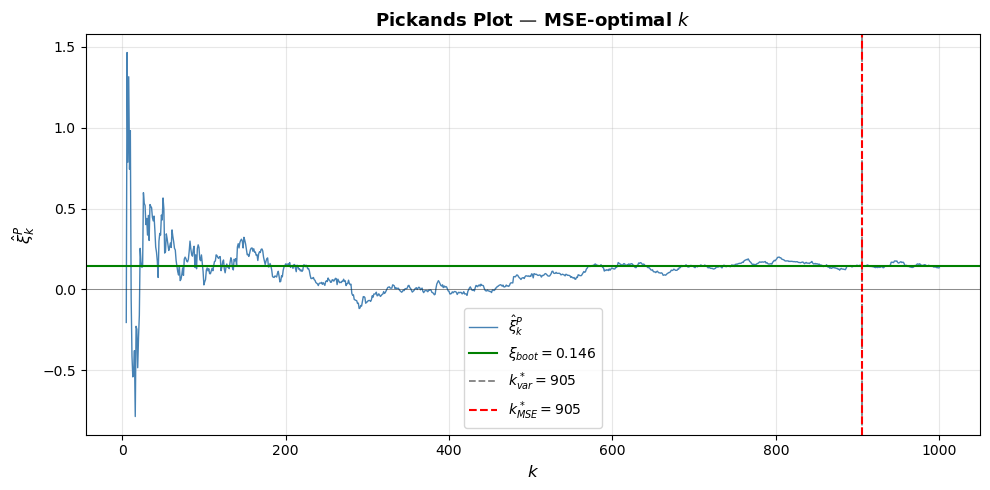

z-stat: 2.297


In [16]:
WINDOW = 20
ks, xis = pickands_estimator(losses, k_min=5, k_max=K_MAX)

k_var, xi_var, _, _, _ = select_k_pickands(ks, xis, window=WINDOW)                    # min-variance criterion
k_mse, xi_mse, mse, bias2, var, ks_v, xis_v = select_k_pickands_mse(ks, xis, XI_BOOT, window=WINDOW)

print(f'min-VAR : k* = {k_var:5d}   xi = {xi_var:.4f}')
print(f'min-MSE : k* = {k_mse:5d}   xi = {xi_mse:.4f}   (xi_boot = {XI_BOOT:.4f})')

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(ks_v, xis_v, color='steelblue', lw=1.0, label='$\\hat{\\xi}_k^P$')
ax.axhline(XI_BOOT, color='green', ls='-', lw=1.5, label=f'$\\xi_{{boot}} = {XI_BOOT:.3f}$')
ax.axvline(k_var, color='gray', ls='--', lw=1.3, label=f'$k^*_{{var}} = {k_var}$')
ax.axvline(k_mse, color='red', ls='--', lw=1.5, label=f'$k^*_{{MSE}} = {k_mse}$')
ax.axhline(0, color='black', lw=0.7, alpha=0.4)
ax.set_xlabel('$k$', fontsize=12); ax.set_ylabel('$\\hat{\\xi}_k^P$', fontsize=12)
ax.set_title('Pickands Plot — MSE-optimal $k$', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

v_asy = (xi_mse**2 * (2**(2*xi_mse + 1) + 1)) / (2*np.log(2) * (2**xi_mse - 1))**2
print(f'z-stat: {xi_mse / np.sqrt(v_asy) * np.sqrt(k_mse):.3f}')

### Hill Plot (diagnostic)

Optimal k*  : 2496
xi_hat (H)  : 0.2721


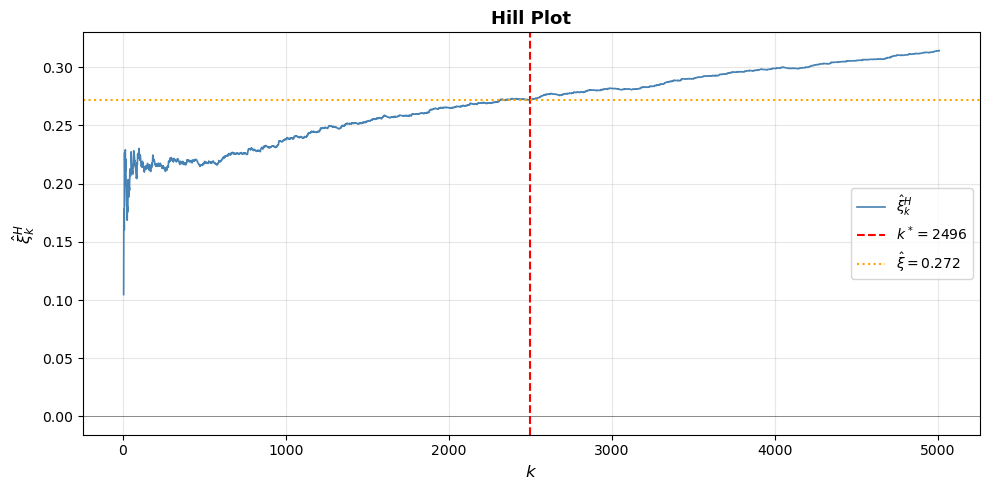

In [17]:
# Hill requires strictly positive data
losses_positive = losses[losses > 0]

# k_max = n//10 — restrict to the true tail, avoid bias from centre
ks_h, xis_h = hill_estimator(losses_positive, k_min=5, k_max=len(losses_positive) // 10)
k_star_h, xi_star_h, ks_v_h, xis_v_h = select_k_hill(ks_h, xis_h, window=20)

print(f'Optimal k*  : {k_star_h}')
print(f'xi_hat (H)  : {xi_star_h:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(ks_v_h, xis_v_h, color='steelblue', linewidth=1.2, label='$\\hat{\\xi}_k^H$')
ax.axvline(k_star_h, color='red', linestyle='--', linewidth=1.5, label=f'$k^* = {k_star_h}$')
ax.axhline(xi_star_h, color='orange', linestyle=':', linewidth=1.5, label=f'$\\hat{{\\xi}} = {xi_star_h:.3f}$')
ax.axhline(0, color='black', linewidth=0.7, linestyle='-', alpha=0.4)
ax.set_xlabel('$k$', fontsize=12)
ax.set_ylabel('$\\hat{\\xi}_k^H$', fontsize=12)
ax.set_title('Hill Plot', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## VII. GEV Quantile & VaR (Pickands $\xi$)

Given the estimated tail index $\hat{\xi}$ from Pickands, we can estimate the $p$-quantile outside the range of observed data using:

$$\hat{x}_{p,k,n} = \frac{\left(\frac{k}{n(1-p)}\right)^{\hat{\xi}} - 1}{1 - 2^{-\hat{\xi}}} \left(X_{k,n} - X_{2k,n}\right) + X_{k,n} \quad \text{(Resnick 6.40)}$$

In [18]:
def quantile_gev(x, p, k, xi):
    n = len(x)
    x_sorted = np.sort(x)[::-1]  # sort descending

    X_k  = x_sorted[k - 1]        # k-th largest
    X_2k = x_sorted[2*k - 1]      # 2k-th largest

    ratio = k / (n * (1 - p))
    q_p = ((ratio**xi - 1) / (1 - 2**(-xi))) * (X_k - X_2k) + X_k

    return q_p


# GEV VaR using the Pickands-estimated tail index (Resnick 6.40)
def var_gev(p, mu, sigma, losses, k, xi):
    q_p = quantile_gev(losses, p, k, xi)
    return -mu + sigma * q_p